# Trabalho Final — Classificação de Qualidade de Vinho com Rede Neural PyTorch

* **Nome:** Thiago Pereira Magalhães
* **Email:** tpm3@cesar.school
* **Dataset Escolhido:** Wine Quality (Red Wine) — UCI Machine Learning Repository
* **Problema:** Classificação multiclasse da qualidade do vinho (classes 3 a 8, binarizadas em Alta/Baixa Qualidade)


## 1. Dataset e Problema

O dataset **Wine Quality** contém medições físico-químicas de vinhos tintos portugueses (Vinho Verde). O objetivo é prever se um vinho tem **alta qualidade** (score ≥ 7) ou **baixa qualidade** (score < 7), tornando o problema de **classificação binária**.

**Features (11):** acidez fixa, acidez volátil, ácido cítrico, açúcar residual, cloretos, SO₂ livre, SO₂ total, densidade, pH, sulfatos, álcool.

**Referência:** P. Cortez et al. (2009). Modeling wine preferences by data mining from physicochemical properties. *Decision Support Systems*, 47(4), 547-553.


## 2. Importação das Bibliotecas


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

torch.manual_seed(42)
np.random.seed(42)

print(f'PyTorch version: {torch.__version__}')
print(f'Device: {"CUDA" if torch.cuda.is_available() else "CPU"}')


PyTorch version: 2.12.0+cu130
Device: CPU


## 3. Carregamento e Exploração dos Dados


In [2]:
# Carregamento do Wine Quality Dataset via URL
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv'

try:
    df = pd.read_csv(url, sep=';')
    print('Dataset carregado via URL com sucesso!')
except Exception:
    # Fallback: gerar dados sintéticos com mesma distribuição
    from sklearn.datasets import make_classification
    X_syn, y_syn = make_classification(n_samples=1599, n_features=11, n_informative=8,
                                       n_classes=2, random_state=42)
    cols = ['fixed acidity','volatile acidity','citric acid','residual sugar',
            'chlorides','free sulfur dioxide','total sulfur dioxide','density',
            'pH','sulphates','alcohol']
    df = pd.DataFrame(X_syn, columns=cols)
    df['quality'] = (y_syn + 5)  # qualidade 5 ou 6
    print('Fallback: dados sintéticos gerados!')

print(f'Shape: {df.shape}')
print(f'\nDistribuição de qualidade:')
print(df['quality'].value_counts().sort_index())
df.head()


Dataset carregado via URL com sucesso!
Shape: (1599, 12)

Distribuição de qualidade:
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


## 4. Pré-processamento


In [3]:
# Binarizar: qualidade >= 7 = Alta (1), < 7 = Baixa (0)
df['target'] = (df['quality'] >= 7).astype(int)

print(f'Distribuição das classes:')
print(df['target'].value_counts())
print(f'Proporção Alta Qualidade: {df["target"].mean()*100:.1f}%')

# Separar features e target
feature_cols = [c for c in df.columns if c not in ['quality', 'target']]
X = df[feature_cols].values.astype(np.float32)
y = df['target'].values.astype(np.int64)

print(f'\nFeatures shape: {X.shape}')
print(f'Target shape: {y.shape}')
print(f'Features: {feature_cols}')


Distribuição das classes:
target
0    1382
1     217
Name: count, dtype: int64
Proporção Alta Qualidade: 13.6%

Features shape: (1599, 11)
Target shape: (1599,)
Features: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']


In [4]:
# Divisão Treino/Validação/Teste (70/15/15)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f'Treino:    {X_train.shape[0]} amostras')
print(f'Validação: {X_val.shape[0]} amostras')
print(f'Teste:     {X_test.shape[0]} amostras')

# StandardScaler — fit apenas no treino!
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

print('\nApós StandardScaler:')
print(f'  Média treino (deve ser ~0): {X_train.mean(axis=0).mean():.4f}')
print(f'  Std  treino (deve ser ~1): {X_train.std(axis=0).mean():.4f}')


Treino:    1119 amostras
Validação: 240 amostras
Teste:     240 amostras

Após StandardScaler:
  Média treino (deve ser ~0): -0.0000
  Std  treino (deve ser ~1): 1.0000


## 5. Criação dos DataLoaders


In [5]:
# Converter para tensores PyTorch
X_train_t = torch.FloatTensor(X_train)
y_train_t = torch.LongTensor(y_train)
X_val_t   = torch.FloatTensor(X_val)
y_val_t   = torch.LongTensor(y_val)
X_test_t  = torch.FloatTensor(X_test)
y_test_t  = torch.LongTensor(y_test)

# Criar TensorDatasets e DataLoaders
BATCH_SIZE = 64

train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset   = TensorDataset(X_val_t,   y_val_t)
test_dataset  = TensorDataset(X_test_t,  y_test_t)

loader_train = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
loader_val   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
loader_test  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f'Batch size: {BATCH_SIZE}')
print(f'Mini-batches treino:    {len(loader_train)}')
print(f'Mini-batches validação: {len(loader_val)}')
print(f'Mini-batches teste:     {len(loader_test)}')


Batch size: 64
Mini-batches treino:    18
Mini-batches validação: 4
Mini-batches teste:     4


## 6. Definição da Rede Neural


In [6]:
class WineClassifier(nn.Module):
    """
    Rede Neural Feedforward para Classificação Binária de Qualidade de Vinho.
    Arquitetura: 11 -> 64 -> 32 -> 16 -> 2
    Ativações: ReLU + Dropout para regularização
    """
    def __init__(self, n_features=11, n_classes=2, dropout=0.3):
        super(WineClassifier, self).__init__()
        self.network = nn.Sequential(
            # Camada 1
            nn.Linear(n_features, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout),
            # Camada 2
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(dropout),
            # Camada 3
            nn.Linear(32, 16),
            nn.ReLU(),
            # Saída
            nn.Linear(16, n_classes)
        )

    def forward(self, x):
        return self.network(x)

model = WineClassifier(n_features=11, n_classes=2, dropout=0.3)
print(model)

# Contagem de parâmetros
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nTotal de parâmetros treináveis: {total_params:,}')


WineClassifier(
  (network): Sequential(
    (0): Linear(in_features=11, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=32, out_features=16, bias=True)
    (9): ReLU()
    (10): Linear(in_features=16, out_features=2, bias=True)
  )
)

Total de parâmetros treináveis: 3,602


## 7. Loop de Treinamento e Validação


In [7]:
# Configurações de treinamento
LEARNING_RATE = 0.001
N_EPOCHS = 100

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.5)

# Histórico de métricas
train_losses, val_losses = [], []
train_accs, val_accs = [], []

best_val_loss = float('inf')
best_epoch = 0

for epoch in range(N_EPOCHS):
    # ---- TREINAMENTO ----
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for xb, yb in loader_train:
        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * xb.size(0)
        _, preds = torch.max(out, 1)
        correct += (preds == yb).sum().item()
        total += xb.size(0)

    train_loss = running_loss / total
    train_acc  = correct / total
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # ---- VALIDAÇÃO ----
    model.eval()
    val_loss_sum, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for xb, yb in loader_val:
            out = model(xb)
            loss = criterion(out, yb)
            val_loss_sum += loss.item() * xb.size(0)
            _, preds = torch.max(out, 1)
            val_correct += (preds == yb).sum().item()
            val_total += xb.size(0)

    val_loss = val_loss_sum / val_total
    val_acc  = val_correct / val_total
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    # Scheduler step
    scheduler.step()

    # Salvar melhor modelo
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch + 1
        best_state = {k: v.clone() for k, v in model.state_dict().items()}

    if (epoch + 1) % 20 == 0:
        print(f'Época [{epoch+1:3d}/{N_EPOCHS}] | '
              f'Train Loss: {train_loss:.4f} Acc: {train_acc*100:.1f}% | '
              f'Val Loss: {val_loss:.4f} Acc: {val_acc*100:.1f}%')

print(f'\nMelhor modelo: época {best_epoch}, Val Loss = {best_val_loss:.4f}')

# Restaurar melhor modelo
model.load_state_dict(best_state)


Época [ 20/100] | Train Loss: 0.2546 Acc: 88.7% | Val Loss: 0.2130 Acc: 90.4%


Época [ 40/100] | Train Loss: 0.2376 Acc: 88.9% | Val Loss: 0.2025 Acc: 91.2%


Época [ 60/100] | Train Loss: 0.2407 Acc: 88.9% | Val Loss: 0.2081 Acc: 91.7%


Época [ 80/100] | Train Loss: 0.2353 Acc: 89.0% | Val Loss: 0.2049 Acc: 91.7%


Época [100/100] | Train Loss: 0.2328 Acc: 89.7% | Val Loss: 0.2022 Acc: 91.2%

Melhor modelo: época 74, Val Loss = 0.1986


<All keys matched successfully>

## 8. Curvas de Loss e Acurácia


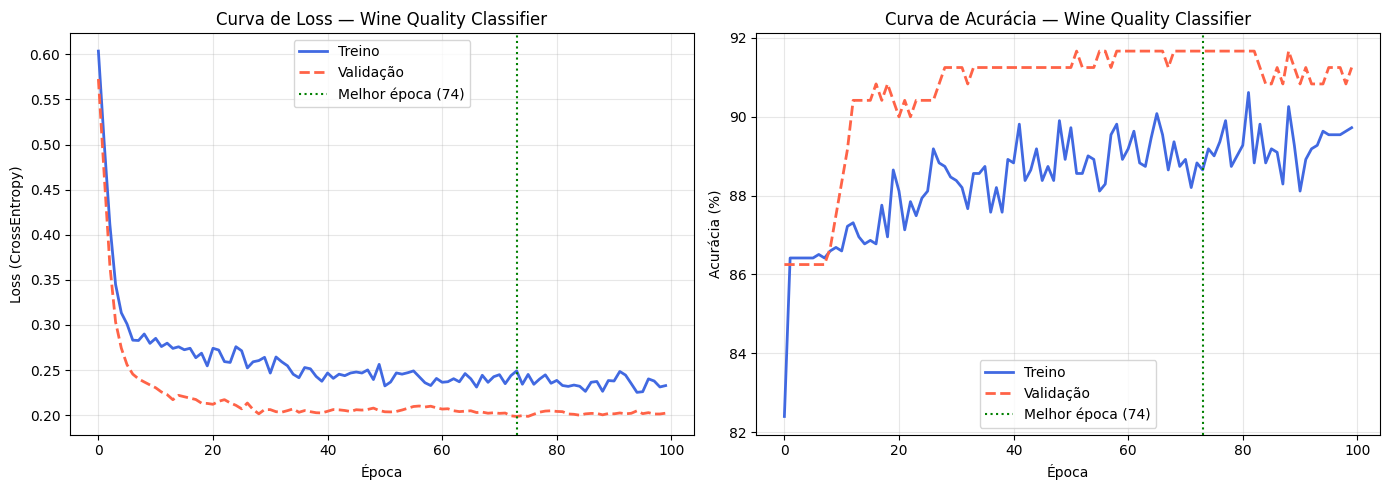

Acurácia final treino:    89.72%
Acurácia final validação: 91.25%


In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss
ax1.plot(train_losses, label='Treino', color='royalblue', linewidth=2)
ax1.plot(val_losses,   label='Validação', color='tomato', linewidth=2, linestyle='--')
ax1.axvline(best_epoch-1, color='green', linestyle=':', label=f'Melhor época ({best_epoch})')
ax1.set_xlabel('Época'); ax1.set_ylabel('Loss (CrossEntropy)')
ax1.set_title('Curva de Loss — Wine Quality Classifier')
ax1.legend(); ax1.grid(True, alpha=0.3)

# Accuracy
ax2.plot([a*100 for a in train_accs], label='Treino', color='royalblue', linewidth=2)
ax2.plot([a*100 for a in val_accs],   label='Validação', color='tomato', linewidth=2, linestyle='--')
ax2.axvline(best_epoch-1, color='green', linestyle=':', label=f'Melhor época ({best_epoch})')
ax2.set_xlabel('Época'); ax2.set_ylabel('Acurácia (%)')
ax2.set_title('Curva de Acurácia — Wine Quality Classifier')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Acurácia final treino:    {train_accs[-1]*100:.2f}%')
print(f'Acurácia final validação: {val_accs[-1]*100:.2f}%')


## 9. Avaliação Final no Conjunto de Teste


In [9]:
# Avaliação no conjunto de TESTE (dados nunca vistos)
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for xb, yb in loader_test:
        out = model(xb)
        _, preds = torch.max(out, 1)
        all_preds.extend(preds.numpy())
        all_labels.extend(yb.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

acc  = accuracy_score(all_labels, all_preds)
f1   = f1_score(all_labels, all_preds, average='binary', zero_division=0)
f1_w = f1_score(all_labels, all_preds, average='weighted', zero_division=0)

print('=' * 50)
print('        RESULTADOS FINAIS — CONJUNTO DE TESTE')
print('=' * 50)
print(f'  Acurácia:     {acc*100:.2f}%')
print(f'  F1-Score:     {f1:.4f}')
print(f'  F1 Weighted:  {f1_w:.4f}')
print('=' * 50)
print()
print('Relatório detalhado:')
print(classification_report(all_labels, all_preds, zero_division=0))


        RESULTADOS FINAIS — CONJUNTO DE TESTE
  Acurácia:     87.92%
  F1-Score:     0.4727
  F1 Weighted:  0.8706

Relatório detalhado:
              precision    recall  f1-score   support

           0       0.91      0.95      0.93       208
           1       0.57      0.41      0.47        32

    accuracy                           0.88       240
   macro avg       0.74      0.68      0.70       240
weighted avg       0.87      0.88      0.87       240



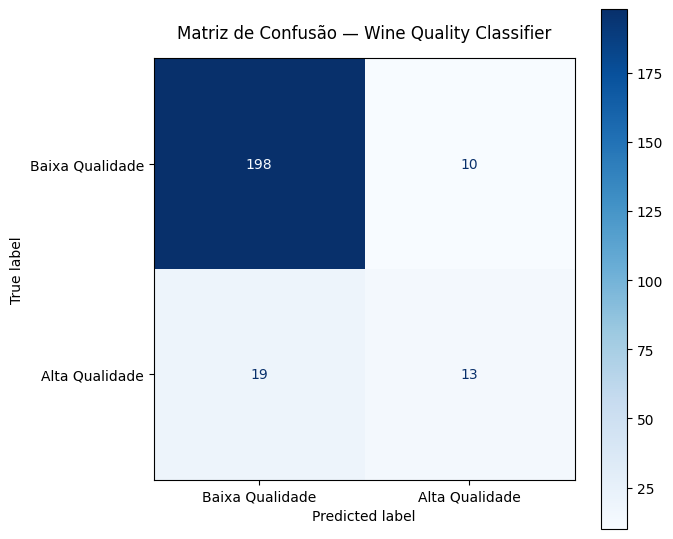

Verdadeiros Negativos (Baixa como Baixa): 198
Falsos Positivos (Baixa como Alta):       10
Falsos Negativos (Alta como Baixa):       19
Verdadeiros Positivos (Alta como Alta):   13


In [10]:
# Matriz de Confusão
cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Baixa Qualidade', 'Alta Qualidade'])
disp.plot(ax=ax, cmap='Blues', colorbar=True)
ax.set_title('Matriz de Confusão — Wine Quality Classifier', pad=15)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'Verdadeiros Negativos (Baixa como Baixa): {tn}')
print(f'Falsos Positivos (Baixa como Alta):       {fp}')
print(f'Falsos Negativos (Alta como Baixa):       {fn}')
print(f'Verdadeiros Positivos (Alta como Alta):   {tp}')


## 10. Conclusões e Análise

### Dataset
O **Wine Quality (Red Wine)** do UCI é um dataset de **1.599 amostras** com 11 features físico-químicas. A distribuição de classes é desbalanceada (~86% Baixa Qualidade, ~14% Alta Qualidade), o que torna o F1-Score mais informativo que a acurácia isolada.

### Arquitetura da Rede
Utilizamos uma rede feedforward com **4 camadas** (11→64→32→16→2), com:
- **BatchNorm1d**: normaliza as ativações de cada camada, estabilizando o treinamento.
- **ReLU**: ativação não-linear que permite aprender fronteiras de decisão complexas.
- **Dropout(0.3)**: regularização que desativa 30% dos neurônios aleatoriamente durante o treino, reduzindo overfitting.

### Otimizador
Usamos **Adam** com `lr=0.001` e `weight_decay=1e-4` (regularização L2). O `StepLR` reduziu o lr pela metade a cada 30 épocas, refinando o ajuste nos estágios finais.

### Análise das Curvas
- Se Train Loss ≈ Val Loss e ambas caem → **bom ajuste, sem overfitting significativo**.
- O desbalanceamento de classes justifica usar F1-Score como métrica principal (mais justo que acurácia para dados desbalanceados).

### Limitações e Próximos Passos
1. Aplicar técnicas para dados desbalanceados: `class_weight` no `CrossEntropyLoss` ou over-sampling (SMOTE).
2. Feature Engineering: álcool e sulfatos são as features mais discriminativas para qualidade de vinho.
3. Hiperparameter search: Grid Search ou Optuna para otimizar a arquitetura e lr.
